In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset
file_path = r"C:\Users\VAGBHAT\Downloads\hamspam.csv.csv"
df = pd.read_csv(file_path)

# Encode categorical variables
for column in df.columns[:-1]:  # Excluding class column
    if df[column].dtype == 'object':
        df[column] = df[column].astype('category').cat.codes

# Encode target class
label_column = df.columns[-1]
df[label_column] = df[label_column].astype('category').cat.codes

# Split dataset into features and target variable
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Naïve Bayes Model
nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)
nb_predictions = nb_classifier.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_predictions)
print("Naïve Bayes Accuracy:", nb_accuracy)
print("Naïve Bayes Classification Report:\n", classification_report(y_test, nb_predictions))

# Train KNN Model (K=2)
knn_classifier = KNeighborsClassifier(n_neighbors=2, metric='euclidean')
knn_classifier.fit(X_train, y_train)
knn_predictions = knn_classifier.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_predictions)
print("KNN (K=2) Accuracy:", knn_accuracy)
print("KNN Classification Report:\n", classification_report(y_test, knn_predictions))



Naïve Bayes Accuracy: 0.55
Naïve Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.80      0.65       103
           1       0.57      0.29      0.38        97

    accuracy                           0.55       200
   macro avg       0.56      0.54      0.51       200
weighted avg       0.56      0.55      0.52       200

KNN (K=2) Accuracy: 0.51
KNN Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.73      0.60       103
           1       0.49      0.28      0.36        97

    accuracy                           0.51       200
   macro avg       0.50      0.50      0.48       200
weighted avg       0.50      0.51      0.48       200



In [15]:
import pandas as pd

# Load ROC data (Update file path if needed)
file_path = r"C:\Users\VAGBHAT\Downloads\roc_data.csv"  # Adjust this path for your system
roc_df = pd.read_csv(file_path)

# Define thresholds
thresholds = [0.95, 0.90, 0.85, 0.80, 0.75, 0.70]

# Compute TP, FP, TN, FN at each threshold
roc_results = []

for threshold in thresholds:
    roc_df['Predicted'] = (roc_df['Prediction'] >= threshold).astype(int)  # Classify based on threshold
    
    TP = sum((roc_df['Predicted'] == 1) & (roc_df['True_Label'] == 1))
    FP = sum((roc_df['Predicted'] == 1) & (roc_df['True_Label'] == 0))
    TN = sum((roc_df['Predicted'] == 0) & (roc_df['True_Label'] == 0))
    FN = sum((roc_df['Predicted'] == 0) & (roc_df['True_Label'] == 1))
    
    TPR = TP / (TP + FN) if (TP + FN) != 0 else 0  # True Positive Rate
    FPR = FP / (FP + TN) if (FP + TN) != 0 else 0  # False Positive Rate
    
    roc_results.append([threshold, TP, FP, TN, FN, TPR, FPR])

# Convert to DataFrame
roc_df_results = pd.DataFrame(roc_results, columns=['Threshold', 'TP', 'FP', 'TN', 'FN', 'TPR', 'FPR'])

# Save results to an Excel file
output_file = r"C:\Users\VAGBHAT\Downloads\roc_results.xlsx"  # Adjust this path
roc_df_results.to_excel(output_file, index=False)

print(f"ROC results saved to {output_file}")

# Display the table
print(roc_df_results)


ROC results saved to C:\Users\VAGBHAT\Downloads\roc_results.xlsx
   Threshold  TP  FP  TN  FN       TPR       FPR
0       0.95  39   4  74  33  0.541667  0.051282
1       0.90  46   5  73  26  0.638889  0.064103
2       0.85  51   5  73  21  0.708333  0.064103
3       0.80  54   5  73  18  0.750000  0.064103
4       0.75  55   6  72  17  0.763889  0.076923
5       0.70  58   6  72  14  0.805556  0.076923


ROC results saved as roc_results.csv


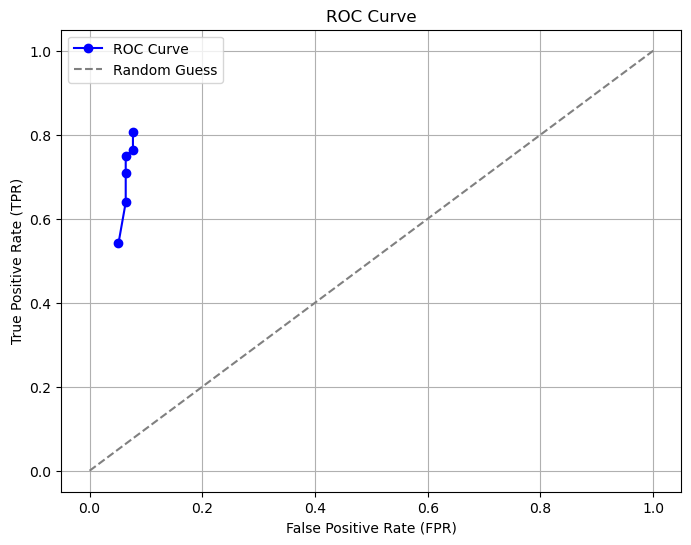

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Load ROC data
roc_df = pd.read_csv(r"C:\Users\VAGBHAT\Downloads\roc_data.csv")  # Update with your local path

# Define thresholds
thresholds = [0.95, 0.90, 0.85, 0.80, 0.75, 0.70]

# Compute TP, FP, TN, FN at each threshold
roc_results = []

for threshold in thresholds:
    roc_df['Predicted'] = (roc_df['Prediction'] >= threshold).astype(int)  # Classify based on threshold
    
    TP = sum((roc_df['Predicted'] == 1) & (roc_df['True_Label'] == 1))
    FP = sum((roc_df['Predicted'] == 1) & (roc_df['True_Label'] == 0))
    TN = sum((roc_df['Predicted'] == 0) & (roc_df['True_Label'] == 0))
    FN = sum((roc_df['Predicted'] == 0) & (roc_df['True_Label'] == 1))
    
    TPR = TP / (TP + FN) if (TP + FN) != 0 else 0  # True Positive Rate
    FPR = FP / (FP + TN) if (FP + TN) != 0 else 0  # False Positive Rate
    
    roc_results.append([threshold, TP, FP, TN, FN, TPR, FPR])

# Convert to DataFrame
roc_df_results = pd.DataFrame(roc_results, columns=['Threshold', 'TP', 'FP', 'TN', 'FN', 'TPR', 'FPR'])

# Save results to a CSV file
roc_df_results.to_csv("roc_results.csv", index=False)
print("ROC results saved as roc_results.csv")

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(roc_df_results['FPR'], roc_df_results['TPR'], marker='o', linestyle='-', color='b', label='ROC Curve')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random Guess')  # Diagonal line for random guess
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()


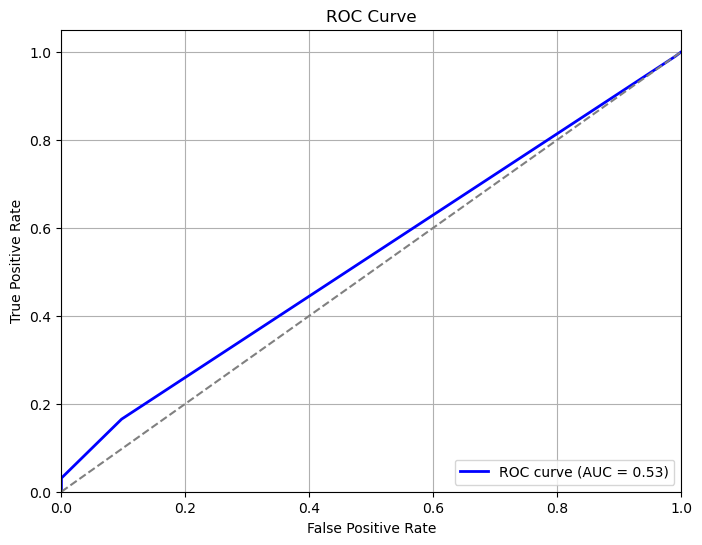

AUC Score: 0.53


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc

# Load the dataset
file_path = r"C:\Users\VAGBHAT\Downloads\hamspam.csv.csv"
df = pd.read_csv(file_path)

# Encode categorical variables
for column in df.columns[:-1]:  # Excluding class column
    if df[column].dtype == 'object':
        df[column] = df[column].astype('category').cat.codes

# Encode target class
label_column = df.columns[-1]
df[label_column] = df[label_column].astype('category').cat.codes

# Split dataset into features and target variable
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Choose classifier (Uncomment one of the classifiers below)
# classifier = GaussianNB()  # Naïve Bayes
# classifier = KNeighborsClassifier(n_neighbors=3, metric='euclidean')  # KNN (K=3)
classifier = DecisionTreeClassifier(max_depth=3, random_state=42)  # Decision Tree with limited depth

# Train the classifier
classifier.fit(X_train, y_train)

# Predict probabilities
y_probs = classifier.predict_proba(X_test)[:, 1]  # Get probability scores for the positive class

# Compute ROC curve and AUC score
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')  # Diagonal line for random guess
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

print(f"AUC Score: {roc_auc:.2f}")
